In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
url = "https://raw.githubusercontent.com/NepalStockData/Nepal_Stock_Data/main/Nepse_Data/Manufacturing_And_Processing/SHIVM.csv"
df = pd.read_csv(url)

In [7]:
df.head()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,1,2026-09-17,685.00,695.00,680.10,685.50,1.36,"396,612.00","272,676,030.80"
1,2,2026-09-16,682.00,687.90,675.00,676.30,-0.69,"243,901.00","165,709,479.50"
2,3,2026-09-15,685.00,690.00,673.00,681.00,1.64,"462,655.00","315,697,044.30"
3,4,2026-09-14,663.00,675.00,663.00,670.00,1.06,"158,053.00","105,980,691.10"
4,5,2026-09-11,659.00,667.00,654.00,663.00,1.44,"104,620.00","69,234,644.80"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S.N.      1707 non-null   int64  
 1   Date      1707 non-null   object 
 2   Open      1707 non-null   object 
 3   High      1707 non-null   object 
 4   Low       1707 non-null   object 
 5   Ltp       1707 non-null   object 
 6   % Change  1707 non-null   float64
 7   Qty       1707 non-null   object 
 8   Turnover  1707 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 120.2+ KB


In [9]:
df[df.isnull().any(axis=1)]

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   S.N.      1707 non-null   int64         
 1   Date      1707 non-null   datetime64[ns]
 2   Open      1707 non-null   object        
 3   High      1707 non-null   object        
 4   Low       1707 non-null   object        
 5   Ltp       1707 non-null   object        
 6   % Change  1707 non-null   float64       
 7   Qty       1707 non-null   object        
 8   Turnover  1707 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 120.2+ KB


In [12]:
df.iloc[:,1:]

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,2026-09-17,685.00,695.00,680.10,685.50,1.36,"396,612.00","272,676,030.80"
1,2026-09-16,682.00,687.90,675.00,676.30,-0.69,"243,901.00","165,709,479.50"
2,2026-09-15,685.00,690.00,673.00,681.00,1.64,"462,655.00","315,697,044.30"
3,2026-09-14,663.00,675.00,663.00,670.00,1.06,"158,053.00","105,980,691.10"
4,2026-09-11,659.00,667.00,654.00,663.00,1.44,"104,620.00","69,234,644.80"
...,...,...,...,...,...,...,...,...
1702,2019-03-28,323.00,353.00,323.00,333.00,-2.06,"78,450.00","26,284,816.00"
1703,2019-03-27,323.00,350.00,306.00,340.00,0.00,"170,472.00","55,440,896.00"
1704,2019-03-26,359.00,359.00,340.00,340.00,-9.81,500.00,"173,150.00"
1705,2019-03-25,398.00,398.00,377.00,377.00,-9.81,90.00,"34,350.00"


In [13]:
cols = ['Open','High','Low','Ltp','Qty','Turnover']

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   S.N.      1707 non-null   int64         
 1   Date      1707 non-null   datetime64[ns]
 2   Open      1707 non-null   float64       
 3   High      1707 non-null   float64       
 4   Low       1707 non-null   float64       
 5   Ltp       1707 non-null   float64       
 6   % Change  1707 non-null   float64       
 7   Qty       1707 non-null   float64       
 8   Turnover  1707 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 120.2 KB


In [15]:
df.nlargest(10, 'Ltp')[['Date','Ltp','Turnover']]


,Date,Ltp,Turnover
1176,2021-08-19,1800.0,325000194.8
1177,2021-08-18,1793.0,420538937.3
1175,2021-08-24,1750.0,192745104.4
1172,2021-08-29,1700.0,183673239.4
1174,2021-08-25,1699.0,209456738.8
1173,2021-08-26,1681.0,112350845.9
1322,2021-01-18,1670.0,86110281.0
1324,2021-01-13,1660.0,163613761.0
1323,2021-01-17,1655.0,96985081.0
1318,2021-01-24,1648.0,104388840.0


In [16]:
df.loc[df['Ltp'].idxmax()]

S.N.                       1177
Date        2021-08-19 00:00:00
Open                     1828.8
High                     1910.0
Low                      1793.0
Ltp                      1800.0
% Change                   0.39
Qty                    176321.0
Turnover            325000194.8
Name: 1176, dtype: object

In [17]:
df.loc[df['Ltp'].idxmin()]

S.N.                       1687
Date        2019-04-22 00:00:00
Open                      305.0
High                      311.0
Low                       304.0
Ltp                       305.0
% Change                    0.0
Qty                     20035.0
Turnover              6140385.0
Name: 1686, dtype: object

In [18]:
df.nsmallest(10, 'Ltp') [[
    'Date','Turnover','Ltp','% Change']]

,Date,Turnover,Ltp,% Change
1686,2019-04-22,6140385.0,305.0,0.00
1687,2019-04-21,5510580.0,305.0,-1.29
1689,2019-04-17,5994927.0,305.0,-1.93
1692,2019-04-11,4957450.0,306.0,-0.65
1684,2019-04-24,7033530.0,307.0,-0.97
1691,2019-04-15,1329135.0,308.0,0.65
1693,2019-04-10,4560692.0,308.0,-0.65
1688,2019-04-18,5411860.0,309.0,1.31
1683,2019-04-25,6451663.0,310.0,0.98
1685,2019-04-23,7136660.0,310.0,1.64


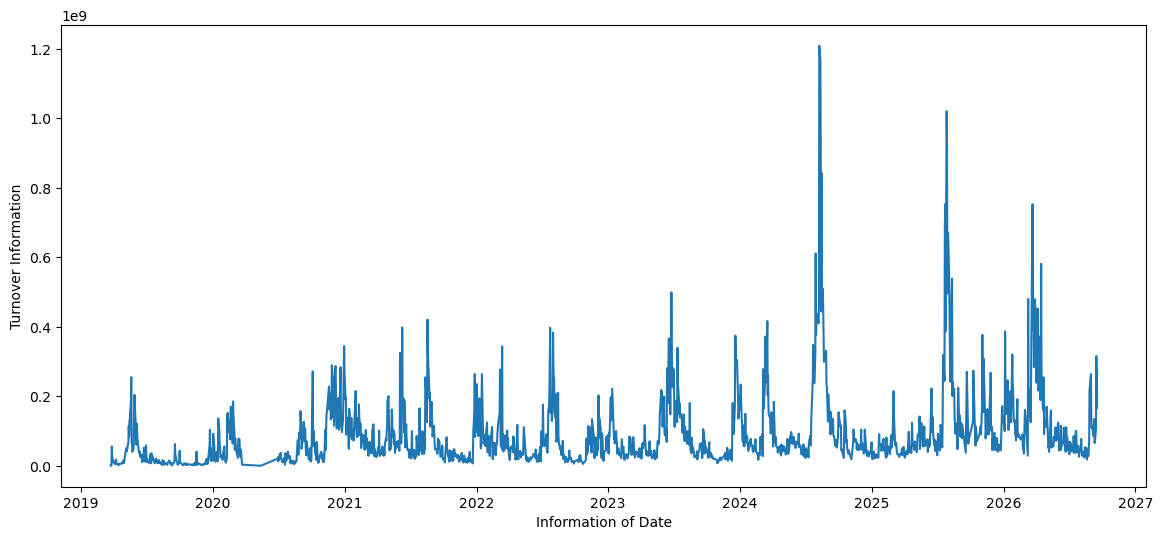

In [19]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'],df['Turnover'])
plt.xlabel("Information of Date")
plt.ylabel("Turnover Information")
plt.show()

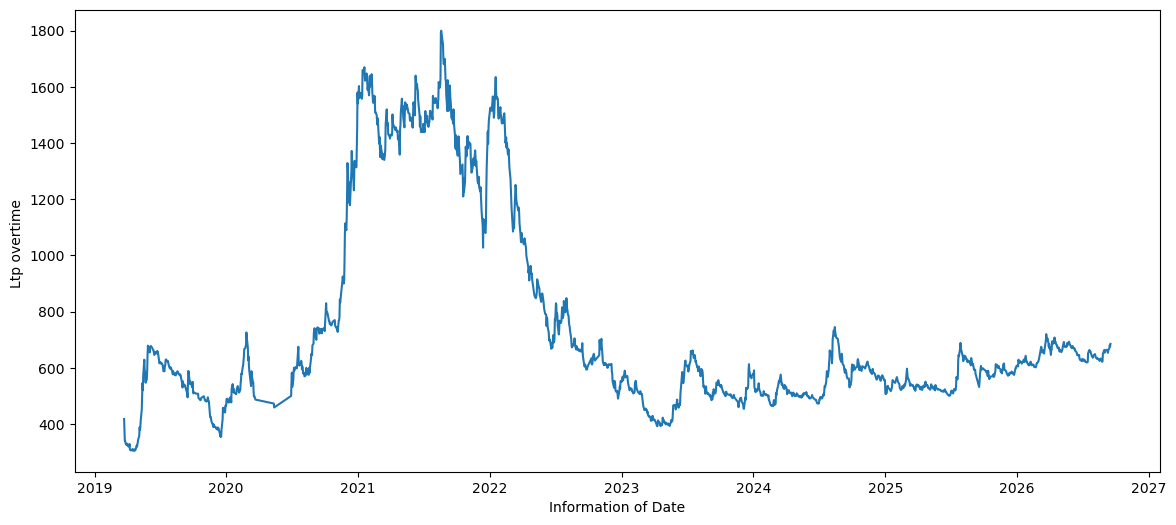

In [20]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'],df['Ltp'])
plt.xlabel("Information of Date")
plt.ylabel("Ltp overtime ")
plt.show()

In [21]:
d_22_26 = (
    (df['Date'] >= '2022-01-01') &
    (df['Date'] <= '2026-12-31')
)

In [22]:
d_22_26 = df[d_22_26]

In [23]:
d_22_26.nlargest(10, 'Ltp') [['Date','Ltp','Turnover']]

,Date,Ltp,Turnover
1082,2022-01-17,1635.0,211235916.2
1083,2022-01-16,1607.0,263378622.7
1081,2022-01-18,1590.0,143744898.5
1088,2022-01-09,1566.0,193989035.5
1079,2022-01-20,1565.0,63536012.1
1080,2022-01-19,1558.0,96432914.3
1078,2022-01-23,1557.1,70327655.3
1087,2022-01-10,1545.0,124449335.5
1073,2022-01-30,1528.0,124497760.7
1093,2022-01-02,1526.0,234981678.8


[]

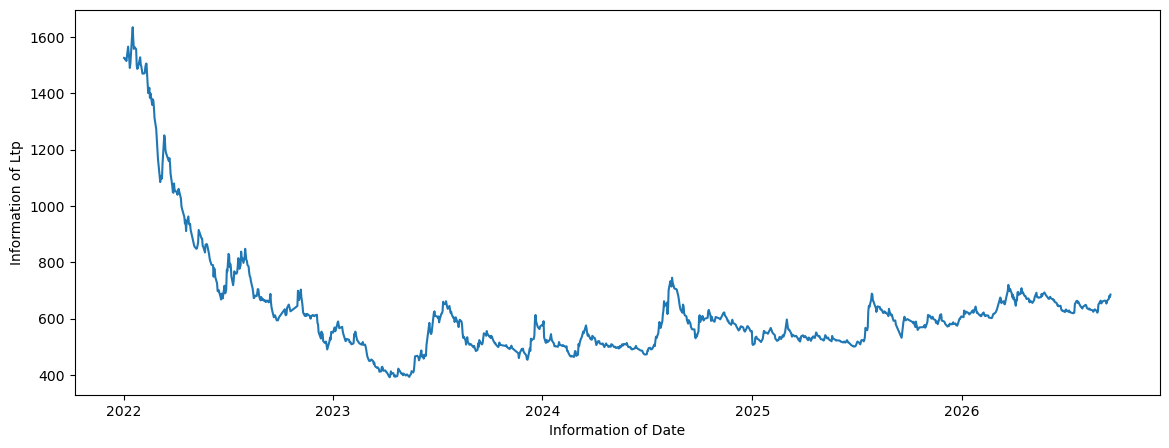

In [24]:
plt.figure(figsize=(14,5))
plt.plot(d_22_26['Date'],d_22_26['Ltp'])
plt.xlabel("Information of Date")
plt.ylabel("Information of Ltp")
plt.plot()           #vey dangerous fall, got less than 40 percent bonus share combined and fall is more than 75% from abpve high..

In [25]:
d_22_26.iloc[d_22_26['Ltp'].idxmax()]

S.N.                       1083
Date        2022-01-17 00:00:00
Open                     1639.1
High                     1671.8
Low                      1580.0
Ltp                      1635.0
% Change                   1.74
Qty                    128877.0
Turnover            211235916.2
Name: 1082, dtype: object

In [26]:
d_22_26.iloc[d_22_26['Ltp'].idxmin()]

S.N.                        791
Date        2023-04-10 00:00:00
Open                      395.0
High                      402.8
Low                       389.8
Ltp                       392.0
% Change                  -0.51
Qty                    173577.0
Turnover             68418643.3
Name: 790, dtype: object

In [27]:
df_20_21 = (
    (df['Date'] >= '2020-01-01') &
    (df['Date'] <= '2021-12-31') 
)

In [28]:
d_20_21 = df[
    (df['Date'] >= '2020-01-01') &
    (df['Date'] <= '2022-12-31')
]

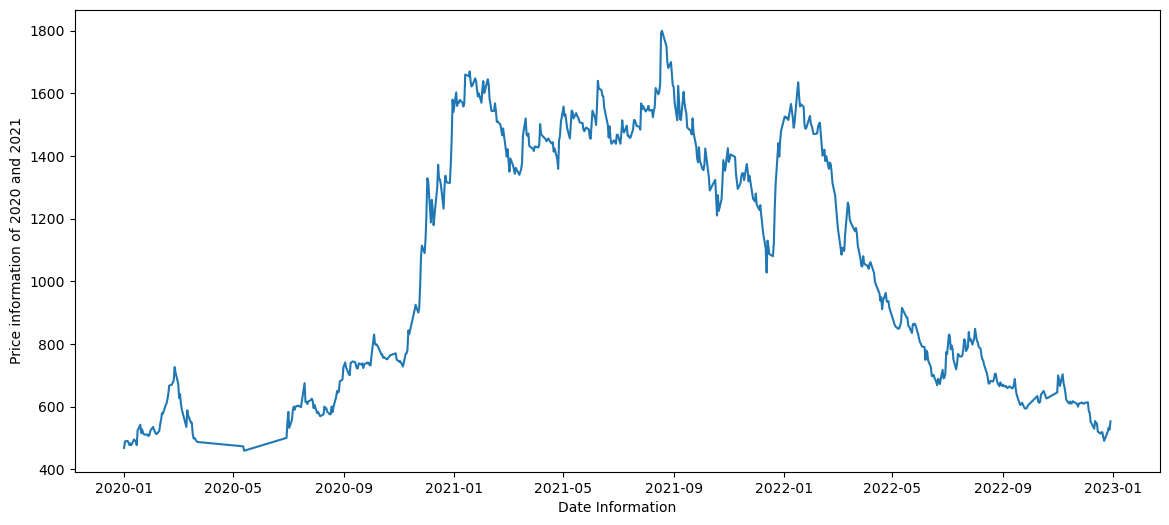

In [29]:
plt.figure(figsize=(14,6))
plt.plot(d_20_21['Date'],d_20_21['Ltp'])
plt.xlabel("Date Information")
plt.ylabel("Price information of 2020 and 2021")
plt.show()

In [30]:
df[df.isnull().any(axis=1)]

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover


[]

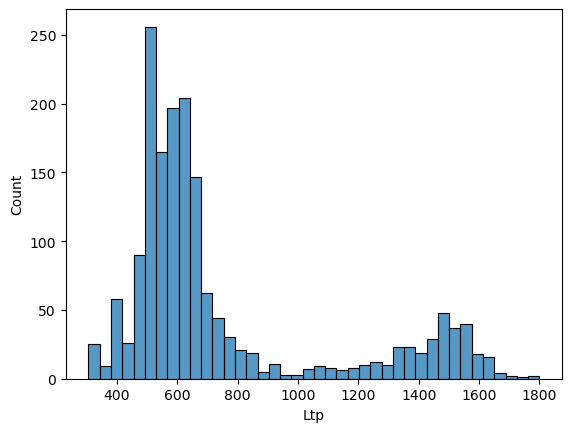

In [31]:
sns.histplot(df['Ltp'])
plt.plot()

[]

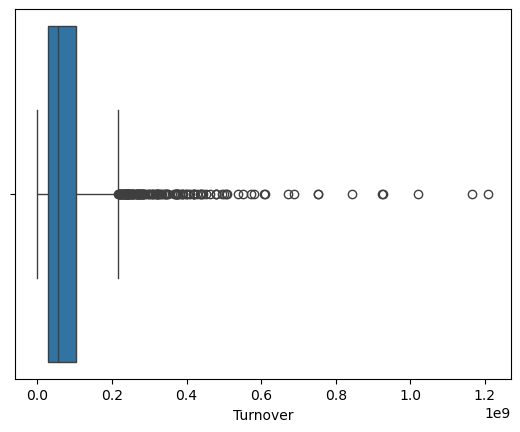

In [32]:
sns.boxplot(x=df['Turnover'])
plt.plot()

[]

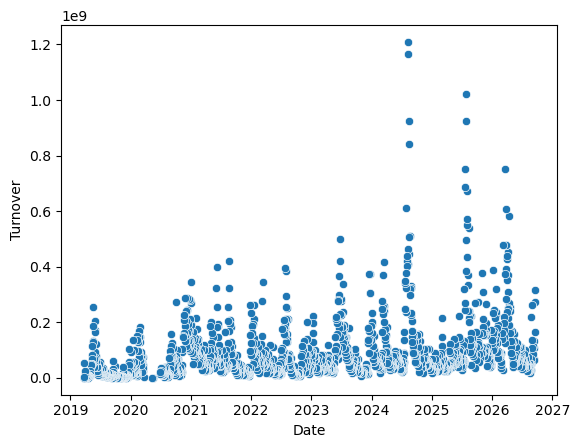

In [33]:
sns.scatterplot(x=df['Date'], y=df['Turnover'])
plt.plot()

[]

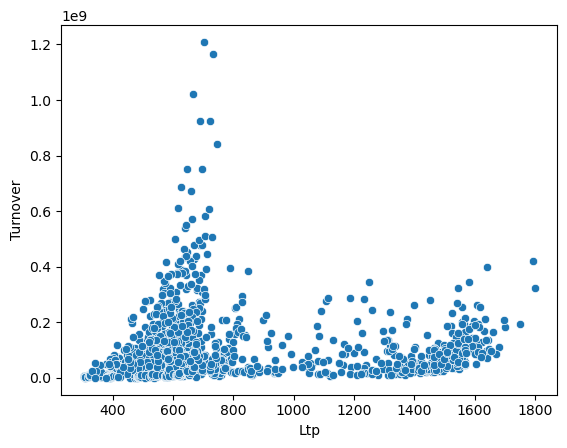

In [34]:
sns.scatterplot(x=df['Ltp'], y=df['Turnover'])
plt.plot()

[]

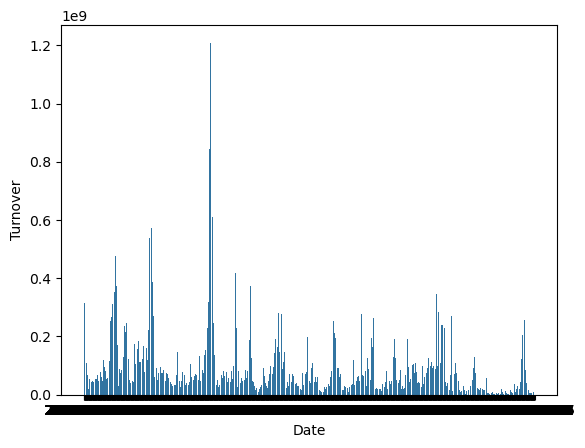

In [35]:
sns.barplot(data=df, x=df['Date'], y=df['Turnover'])
plt.plot()

In [36]:
seventy_fifth = df['Ltp'].quantile(0.75)
twenty_fifth = df['Ltp'].quantile(0.25)
iqr = seventy_fifth-twenty_fifth
print(iqr)

226.635


In [37]:
upper = seventy_fifth+(1.5*iqr)
lower = twenty_fifth+(1.5*iqr)
print(upper, lower)

1090.4524999999999 863.8175


In [38]:
df['Year'] = df['Date'].dt.year

In [39]:
df.groupby('Year').agg(
    Average_Ltp=("Ltp", "mean"),
    Max_Ltp=("Ltp","max"),
    Min_Ltp=("Ltp","min")
)

,Average_Ltp,Max_Ltp,Min_Ltp
Year,,,
2019,502.478947,679.00,305.00
2020,735.521739,1580.00,459.00
2021,1464.419665,1800.00,1027.90
2022,886.716116,1635.00,490.60
2023,507.206167,662.00,392.00
2024,549.012069,745.10,463.90
2025,561.268844,688.64,501.05
2026,649.913690,720.00,601.90


In [40]:
df[df['% Change'].abs() > 9]

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover,Year
226,227,2025-09-21,532.0,585.2,532.0,585.2,10.00,474462.0,2.701141e+08,2025
261,262,2025-07-22,575.0,626.0,570.1,626.0,9.99,1128704.0,6.883189e+08,2025
479,480,2024-08-08,650.7,701.8,632.0,701.8,10.00,1795316.0,1.209010e+09,2024
630,631,2023-12-19,549.8,594.0,549.0,594.0,10.00,648095.0,3.743482e+08,2023
739,740,2023-06-25,554.0,605.9,547.0,605.9,9.98,844474.0,4.990739e+08,2023
973,974,2022-06-30,719.0,775.5,710.0,774.0,9.79,132607.0,9.952063e+07,2022
1097,1098,2021-12-26,1337.2,1441.0,1311.0,1441.0,9.92,111489.0,1.552073e+08,2021
1099,1100,2021-12-22,1140.0,1234.2,1132.0,1234.2,10.00,29030.0,3.515697e+07,2021
1104,1105,2021-12-14,1048.0,1129.9,1030.0,1129.8,9.91,11204.0,1.213884e+07,2021
1177,1178,2021-08-18,1649.0,1793.0,1640.0,1793.0,10.00,239956.0,4.205389e+08,2021


In [41]:
df['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1707 entries, 0 to 1706
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
1707 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 13.5 KB


In [ ]:
df['Year'].head()

In [ ]:
df[['Date', 'Year']].head()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].info()

In [ ]:
df['Year'] = df['Date'].dt.year

In [65]:
df['Month'] = df['Date'].dt.month

In [ ]:
df[['Date','Year','Month']].head(10)

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly = df.groupby(['Year','Month']).agg(
    Avg_Price = ('Ltp','mean'),
    Highest_Ltp = ('Ltp','max'),
    Lowest_Ltp = ('Ltp','min'),
    Total_Turnover = ('Turnover','sum')
)

In [ ]:
print(monthly)

In [ ]:
sns.histplot(df['Turnover'], bins=30)
plt.show()

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   S.N.      1707 non-null   int64         
 1   Date      1707 non-null   datetime64[ns]
 2   Open      1707 non-null   float64       
 3   High      1707 non-null   float64       
 4   Low       1707 non-null   float64       
 5   Ltp       1707 non-null   float64       
 6   % Change  1707 non-null   float64       
 7   Qty       1707 non-null   float64       
 8   Turnover  1707 non-null   float64       
 9   Year      1707 non-null   int32         
dtypes: datetime64[ns](1), float64(7), int32(1), int64(1)
memory usage: 126.8 KB


In [61]:
df[['Ltp', 'Open', 'High', 'Low', 'Qty', 'Turnover', '% Change']].corr()

,Ltp,Open,High,Low,Qty,Turnover,% Change
Ltp,1.000000,0.997738,0.999281,0.998904,-0.152518,0.074791,0.020668
Open,0.997738,1.000000,0.998809,0.999131,-0.159168,0.066749,-0.030892
High,0.999281,0.998809,1.000000,0.998869,-0.150344,0.077388,-0.001257
Low,0.998904,0.999131,0.998869,1.000000,-0.161739,0.063676,-0.013209
Qty,-0.152518,-0.159168,-0.150344,-0.161739,1.000000,0.955972,0.183507
Turnover,0.074791,0.066749,0.077388,0.063676,0.955972,1.000000,0.190886
% Change,0.020668,-0.030892,-0.001257,-0.013209,0.183507,0.190886,1.000000


In [63]:
df['% Change'].std()

0.026607072564151752

In [67]:
df['Month'] = df['Date'].dt.month
volatility = df.groupby(['Year', 'Month'])['% Change'].std()

In [68]:
volatility

Year  Month
2019  3        0.046008
      4        0.021080
      5        0.056442
      6        0.016729
      7        0.013142
                 ...   
2026  5        0.011110
      6        0.006518
      7        0.013104
      8        0.012139
      9        0.011070
Name: % Change, Length: 90, dtype: float64

In [73]:
df['Day'] = df['Date'].dt.day_name()

df.groupby('Day')["Ltp"].agg(
    ['mean','min','max','std']
)

,mean,min,max,std
Day,,,,
Friday,697.388235,621.5,860.0,66.808314
Monday,752.559550,305.0,1670.0,357.138730
Sunday,748.472443,305.0,1700.0,369.848425
Thursday,742.057189,306.0,1800.0,353.899831
Tuesday,747.512931,310.0,1750.0,359.485528
Wednesday,744.443199,305.0,1793.0,352.910235


In [77]:
df['Price_Range'] = df['High'] - df['Low']
print(df['Price_Range'])

0       14.9
1       12.9
2       17.0
3       12.0
4       13.0
        ... 
1702    30.0
1703    44.0
1704    19.0
1705    21.0
1706    46.0
Name: Price_Range, Length: 1707, dtype: float64


In [86]:
df['Ltp'].kurt()

np.float64(0.5417630995467526)

In [85]:
df['Ltp'].corr(df['Turnover'])


np.float64(0.07479132522827898)

In [87]:
df['Ltp'].mean()

np.float64(745.9673052138254)

In [88]:
df['Ltp'].var()

125789.51728933398

In [89]:
df['Ltp'].skew()

np.float64(1.4012394679432683)

In [93]:
df['Ltp'].cov(df['Turnover'])

np.float64(2863340432.688075)

In [101]:
df = df.sort_values('Date').reset_index(drop=True)

In [102]:
df.head()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover,Year,Month,Day,Price_Range,Ltp_Lag1,Return_Lag1,Target_Up
0,1707,2019-03-24,464.0,464.0,418.0,418.0,0.0000,3920.0,1737870.0,2019,3,Sunday,46.0,NaN,NaN,0
1,1706,2019-03-25,398.0,398.0,377.0,377.0,-0.0981,90.0,34350.0,2019,3,Monday,21.0,418.0,0.0000,0
2,1705,2019-03-26,359.0,359.0,340.0,340.0,-0.0981,500.0,173150.0,2019,3,Tuesday,19.0,377.0,-0.0981,0
3,1704,2019-03-27,323.0,350.0,306.0,340.0,0.0000,170472.0,55440896.0,2019,3,Wednesday,44.0,340.0,-0.0981,0
4,1703,2019-03-28,323.0,353.0,323.0,333.0,-0.0206,78450.0,26284816.0,2019,3,Thursday,30.0,340.0,0.0000,0


In [99]:
# Lagged Features (Previous day's close and return)
df['Ltp_Lag1'] = df['Ltp'].shift(1)
df['Return_Lag1'] = df['% Change'].shift(1)

# Target Variable: Predict if tomorrow's price goes UP (1) or DOWN (0)
df['Target_Up'] = (df['Ltp'].shift(-1) > df['Ltp']).astype(int)

In [107]:
df['Difference'] = df["High"] - df['Low']

In [109]:
df[df['Difference'] > 15]

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover,Year,Month,Day,Price_Range,Ltp_Lag1,Return_Lag1,Target_Up,Difference
0,1707,2019-03-24,464.0,464.0,418.0,418.0,0.0000,3920.0,1737870.0,2019,3,Sunday,46.0,NaN,NaN,0,46.0
1,1706,2019-03-25,398.0,398.0,377.0,377.0,-0.0981,90.0,34350.0,2019,3,Monday,21.0,418.0,0.0000,0,21.0
2,1705,2019-03-26,359.0,359.0,340.0,340.0,-0.0981,500.0,173150.0,2019,3,Tuesday,19.0,377.0,-0.0981,0,19.0
3,1704,2019-03-27,323.0,350.0,306.0,340.0,0.0000,170472.0,55440896.0,2019,3,Wednesday,44.0,340.0,-0.0981,0,44.0
4,1703,2019-03-28,323.0,353.0,323.0,333.0,-0.0206,78450.0,26284816.0,2019,3,Thursday,30.0,340.0,0.0000,0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,11,2026-09-01,661.0,672.0,648.0,654.0,-0.0151,207849.0,136398370.8,2026,9,Tuesday,24.0,664.0,0.0215,1,24.0
1697,10,2026-09-02,657.0,668.0,648.0,658.0,0.0061,165180.0,108967119.8,2026,9,Wednesday,20.0,654.0,-0.0151,1,20.0
1699,8,2026-09-07,694.0,694.0,660.0,664.2,0.0048,128175.0,85396612.6,2026,9,Monday,34.0,661.0,0.0046,0,34.0
1700,7,2026-09-09,664.2,678.8,660.0,662.6,-0.0024,200599.0,134606507.5,2026,9,Wednesday,18.8,664.2,0.0048,0,18.8


In [110]:
df[['Ltp', 'Open', 'High', 'Low', 'Qty', 'Turnover', '% Change']].corr()

,Ltp,Open,High,Low,Qty,Turnover,% Change
Ltp,1.000000,0.997738,0.999281,0.998904,-0.152518,0.074791,0.020668
Open,0.997738,1.000000,0.998809,0.999131,-0.159168,0.066749,-0.030892
High,0.999281,0.998809,1.000000,0.998869,-0.150344,0.077388,-0.001257
Low,0.998904,0.999131,0.998869,1.000000,-0.161739,0.063676,-0.013209
Qty,-0.152518,-0.159168,-0.150344,-0.161739,1.000000,0.955972,0.183507
Turnover,0.074791,0.066749,0.077388,0.063676,0.955972,1.000000,0.190886
% Change,0.020668,-0.030892,-0.001257,-0.013209,0.183507,0.190886,1.000000


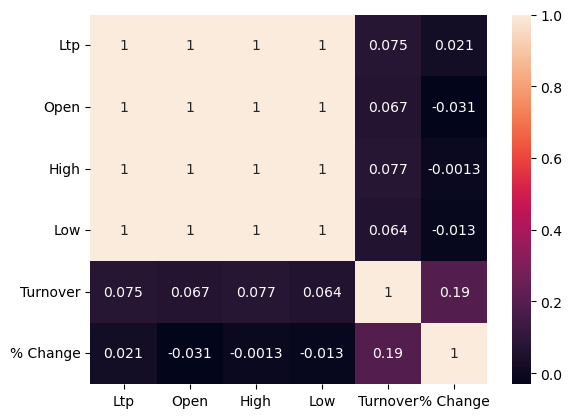

In [111]:
sns.heatmap(
    df[['Ltp','Open','High','Low','Turnover','% Change']].corr(),
    annot = True
)
plt.show()

In [115]:
monthly_vol = df.groupby(['Year','Month'])['% Change'].std()
print(monthly_vol)

Year  Month
2019  3        0.046008
      4        0.021080
      5        0.056442
      6        0.016729
      7        0.013142
                 ...   
2026  5        0.011110
      6        0.006518
      7        0.013104
      8        0.012139
      9        0.011070
Name: % Change, Length: 90, dtype: float64


In [127]:
df['SMA_5'] = df['Ltp'].rolling(window=5).mean()
df['SMA_20'] = df['Ltp'].rolling(window=20).mean()

In [120]:
df['Average_Price_share'] = df['Turnover'] / df['Qty']

In [121]:
print(df['Average_Price_share'])

0       443.334184
1       381.666667
2       346.300000
3       325.219954
4       335.051829
           ...    
1702    661.772556
1703    670.538940
1704    682.359521
1705    679.412874
1706    687.513315
Name: Average_Price_share, Length: 1707, dtype: float64


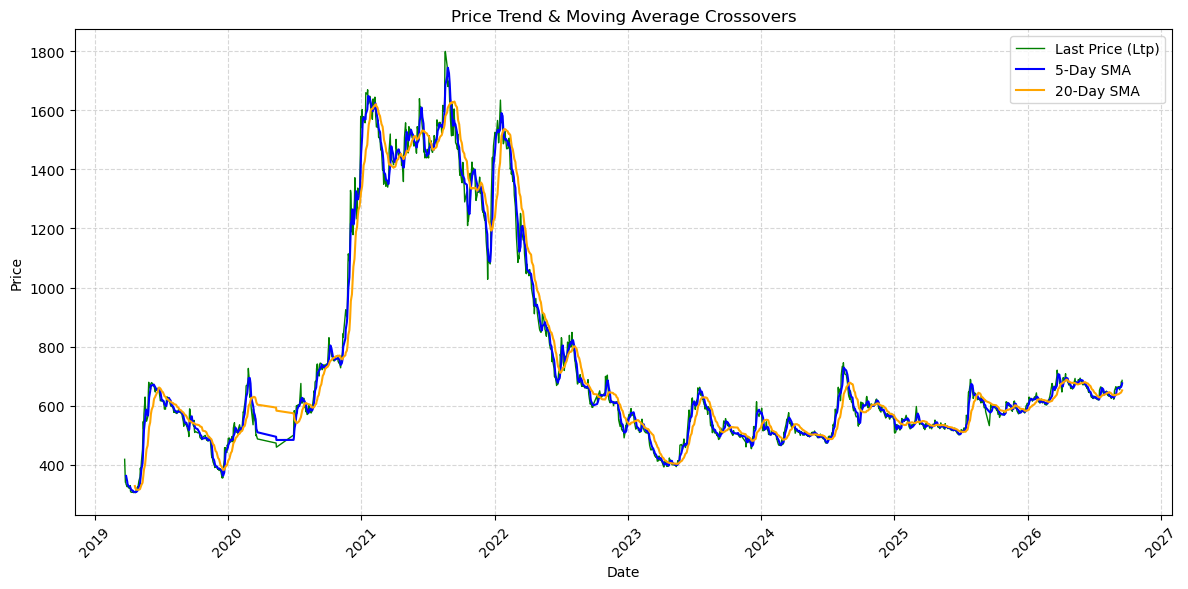

In [126]:

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Ltp'], label='Last Price (Ltp)', color='green', linewidth=1)
plt.plot(df['Date'], df['SMA_5'], label='5-Day SMA', color='blue', linewidth=1.5)
plt.plot(df['Date'], df['SMA_20'], label='20-Day SMA', color='orange', linewidth=1.5)

plt.title('Price Trend & Moving Average Crossovers')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [128]:
df['Volatility_20D'] = df['% Change'].rolling(window=20).std()

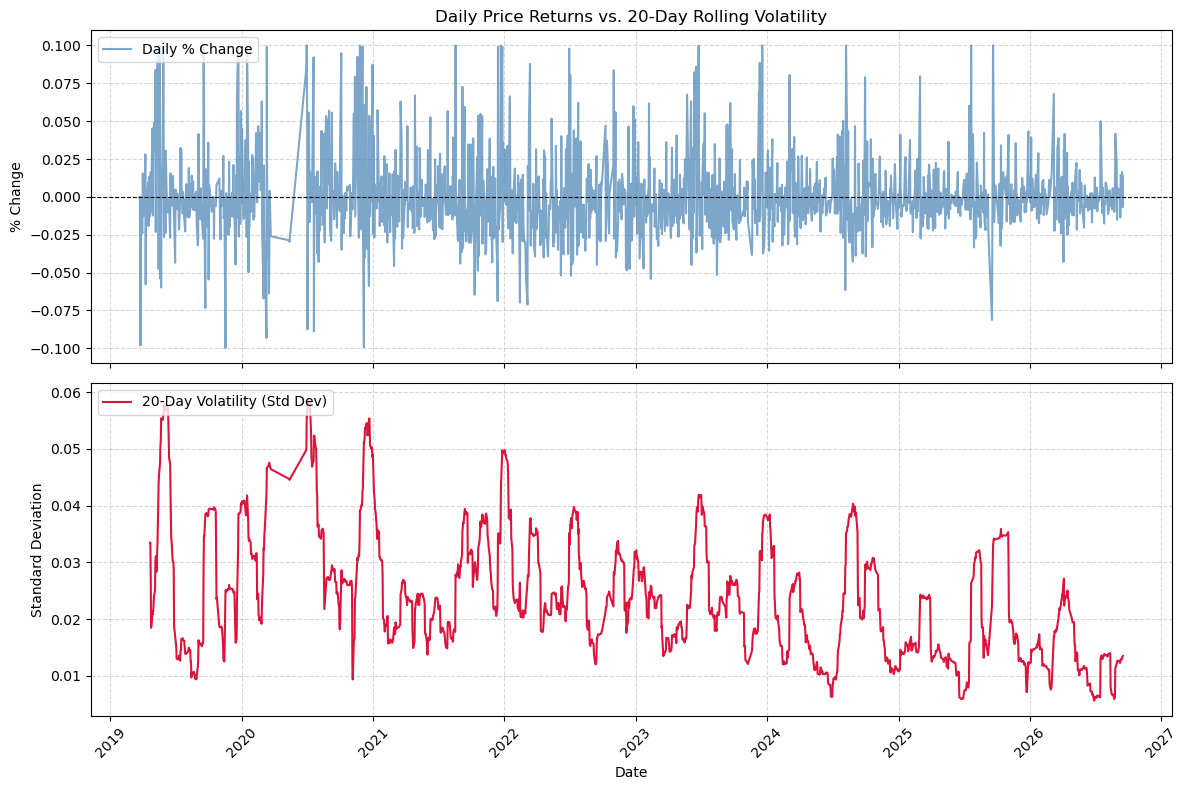

In [132]:
import matplotlib.pyplot as plt
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df['Volatility_20D'] = df['% Change'].rolling(window=20).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df['Date'], df['% Change'], color='steelblue', alpha=0.7, label='Daily % Change')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_ylabel('% Change')
ax1.set_title('Daily Price Returns vs. 20-Day Rolling Volatility')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df['Date'], df['Volatility_20D'], color='crimson', linewidth=1.5, label='20-Day Volatility (Std Dev)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Standard Deviation')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()